### Part-B Question's Solution

#### MLC Minor Assignment - 1

#### Question-1

1. Generate synthetic datasets for clustering. 
- a) Use make_blobs( ) to create a dataset with 3 clusters.  
     Note: make_blobs( ) is a function in scikit-learn used to generate synthetic datasets with clusters. 
- b) Visualize the dataset using a scatter plot. 
- c) Change the number of clusters and observe the results. 

First 5 data points:
[[-7.33898809 -7.72995396]
 [-7.74004056 -7.26466514]
 [-1.68665271  7.79344248]
 [ 4.42219763  3.07194654]
 [-8.91775173 -7.8881959 ]]


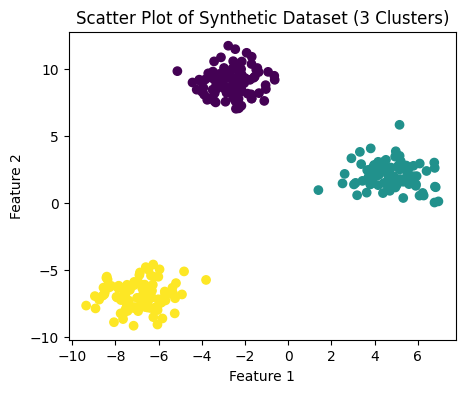

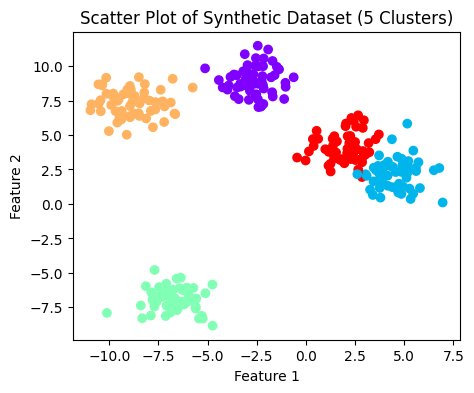

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

## 1(a)
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

print("First 5 data points:")
print(X[:5])

## 1(b)
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')
plt.title("Scatter Plot of Synthetic Dataset (3 Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 1(c)
X_new, y_new = make_blobs(n_samples=300, centers=5, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X_new[:,0], X_new[:,1], c=y_new, cmap='rainbow')
plt.title("Scatter Plot of Synthetic Dataset (5 Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

#### Question-2

2. Determine the optimal number of clusters using Elbow Method  
- a) Generate a dataset using make_blobs( ). 
- b) Apply K-Means for different values of k (k=1 to 9). 
- c) Calculate inertia (sum of squared distances). 
- d) Plot the Elbow graph.

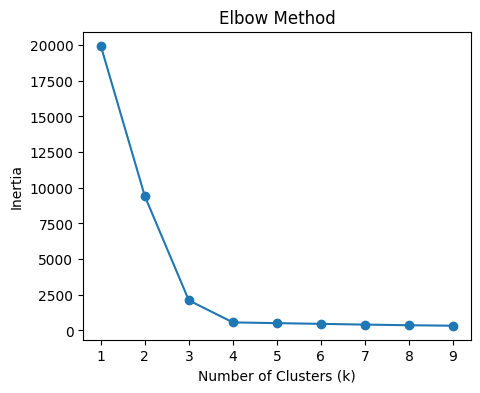

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## 2(a)
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

## 2(b)
inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

## 2(c)
plt.figure(figsize=(5,4))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

#### Question-3

3. Perform clustering using K-Means on a synthetic dataset. 
- a) Generate a dataset using make_blobs( ). 
- b) Apply the K-Means algorithm. 
- c) Change the number of clusters from 2 to 5. 
- d) Plot clusters and centroids. 
- e) Observe how cluster formation changes. 

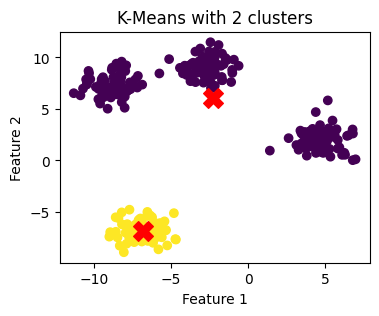

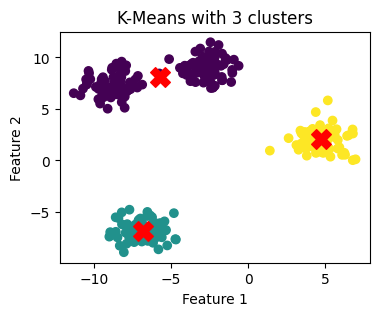

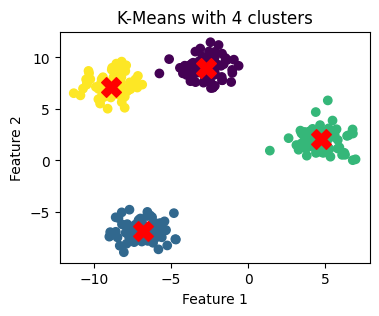

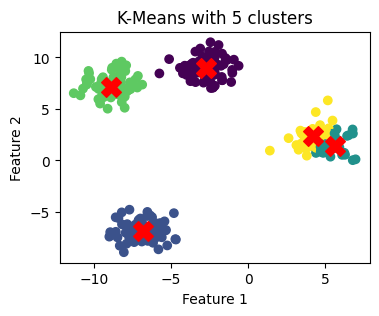

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## 3(a)
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

## 3(b)
for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    ## 3(c)
    plt.figure(figsize=(4,3))
    plt.scatter(X[:,0], X[:,1], c=labels)
    
    ## 3(d)
    plt.scatter(kmeans.cluster_centers_[:,0],
                kmeans.cluster_centers_[:,1],
                s=200, c='red', marker='X')

    ## 3(e)
    plt.title(f"K-Means with {k} clusters")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

#### Question-4

4. Perform clustering using Hierarchical Clustering on a synthetic dataset. 
- a) Generate a dataset using make_blobs( ). 
- b) Apply Agglomerative Clustering. 
- c) Plot a dendrogram. 
- d) Compare results with K-Means clustering. 

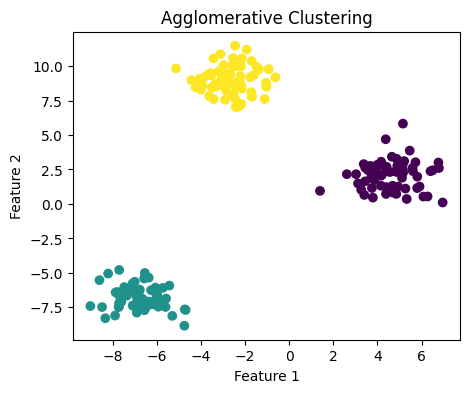

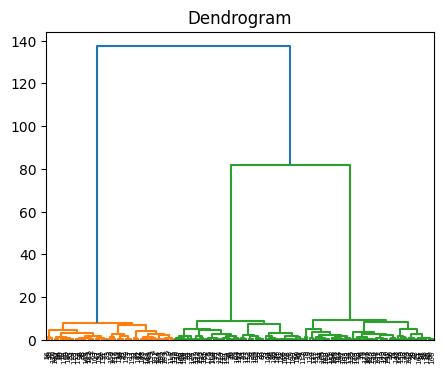

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

## 4(a)
X, y = make_blobs(n_samples=200, centers=3, random_state=42)

## 4(b)
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

## 4(c)
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4(d)
plt.figure(figsize=(5,4))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

#### Question-5

5. Find patterns using association rules. 
- a) Create a small transaction dataset. 
- b) Apply the Apriori algorithm. 
- c) Calculate support and confidence. 
- d) Generate association rules.

In [5]:
import pandas as pd
from itertools import combinations

## 5(a)
data = {
    'Milk':[1,1,0,1,0],
    'Bread':[1,1,1,0,1],
    'Butter':[0,1,1,1,0],
    'Eggs':[1,0,1,1,1]
}

## 5(b)
df = pd.DataFrame(data)

print("Transaction Dataset:")
print(df)

items = df.columns
min_support = 0.4
frequent_itemsets = {}

## 5(c)
for i in range(1, len(items)+1):
    for combo in combinations(items, i):
        support = df[list(combo)].all(axis=1).mean()
        if support >= min_support:
            frequent_itemsets[combo] = support

print("\nFrequent Itemsets:")
for itemset, support in frequent_itemsets.items():
    print(itemset, "Support:", support)

## 5(d)
print("\nAssociation Rules:")
for itemset in frequent_itemsets:
    if len(itemset) > 1:
        for i in range(len(itemset)):
            antecedent = (itemset[i],)
            consequent = tuple(x for x in itemset if x != itemset[i])

            support_itemset = frequent_itemsets[itemset]
            support_antecedent = df[list(antecedent)].all(axis=1).mean()
            confidence = support_itemset / support_antecedent

            print(antecedent, "->", consequent,
                "Support:", round(support_itemset,2),
                "Confidence:", round(confidence,2))

Transaction Dataset:
   Milk  Bread  Butter  Eggs
0     1      1       0     1
1     1      1       1     0
2     0      1       1     1
3     1      0       1     1
4     0      1       0     1

Frequent Itemsets:
('Milk',) Support: 0.6
('Bread',) Support: 0.8
('Butter',) Support: 0.6
('Eggs',) Support: 0.8
('Milk', 'Bread') Support: 0.4
('Milk', 'Butter') Support: 0.4
('Milk', 'Eggs') Support: 0.4
('Bread', 'Butter') Support: 0.4
('Bread', 'Eggs') Support: 0.6
('Butter', 'Eggs') Support: 0.4

Association Rules:
('Milk',) -> ('Bread',) Support: 0.4 Confidence: 0.67
('Bread',) -> ('Milk',) Support: 0.4 Confidence: 0.5
('Milk',) -> ('Butter',) Support: 0.4 Confidence: 0.67
('Butter',) -> ('Milk',) Support: 0.4 Confidence: 0.67
('Milk',) -> ('Eggs',) Support: 0.4 Confidence: 0.67
('Eggs',) -> ('Milk',) Support: 0.4 Confidence: 0.5
('Bread',) -> ('Butter',) Support: 0.4 Confidence: 0.5
('Butter',) -> ('Bread',) Support: 0.4 Confidence: 0.67
('Bread',) -> ('Eggs',) Support: 0.6 Confidence:

#### Question-6

6. Implement Artificial Neuron Calculation. 
- a) Take input values x1, x2, x3. 
- b) Assign weights w1, w2, w3. 
- c) Compute neuron output using: y=f(w1x1+w2x2+w3x3+b)  
- d) Implement it using each of the following activation function:  step function, Sigmoid function, Tanh function, ReLU function 

In [6]:
import numpy as np

## 6(a)
x = np.array([1,2,3])
w = np.array([0.5,0.3,0.2])
b = 0.1
z = np.dot(w,x) + b

## 6(b)
step = 1 if z >= 0 else 0
print("Step Function:", step)

## 6(c)
sigmoid = 1/(1+np.exp(-z))
print("Sigmoid:", sigmoid)

## 6(d)
tanh = np.tanh(z)
print("Tanh:", tanh)

relu = max(0,z)
print("ReLU:", relu)

Step Function: 1
Sigmoid: 0.8581489350995123
Tanh: 0.9468060128462683
ReLU: 1.8000000000000003


#### Question-7

7. Train a perceptron classifier on a synthetic dataset. 
- a) Generate a dataset using make_classification( ). 
- b) Train a perceptron classifier. 
- c) Plot the decision boundary. 
- d) Identify misclassified points and compute accuracy.

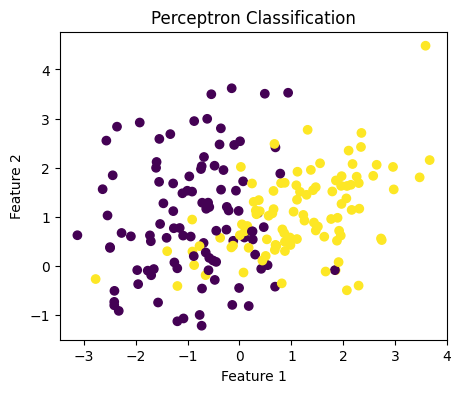

Accuracy: 0.845


In [7]:
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

## 7(a)
X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           random_state=42)

## 7(b)
model = Perceptron()
model.fit(X,y)

## 7(c)
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Perceptron Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 7(d)
accuracy = model.score(X,y)
print("Accuracy:", accuracy)

#### Question-8

8. Implement a neural network classifier using MLPClassifier 
- a) Create a dataset. 
- b) Train a neural network classifier.  
- c) Change number of hidden layers. 
- d) Compare model accuracy.

In [8]:
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier

## 8(a)
X, y = make_classification(n_samples=300, n_features=4, random_state=42)

## 8(b)
model1 = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000)
model1.fit(X,y)

## 8(c)
model2 = MLPClassifier(hidden_layer_sizes=(10,5), max_iter=1000)
model2.fit(X,y)

## 8(d)
print("Accuracy Model1:", model1.score(X,y))
print("Accuracy Model2:", model2.score(X,y))

Accuracy Model1: 0.94
Accuracy Model2: 0.9766666666666667


#### Question-9

9. Design a neural network with one hidden layer and train it using backpropagation to classify two classes. 
- a) Create or load a small dataset containing two classes and split it into training and testing sets. 
- b) Design the neural network architecture with an input layer, one hidden layer, and an output layer. Initialize weights and biases. 
- c) Perform forward propagation to compute the predicted output using an activation function. 
- d) Apply the backpropagation algorithm to update weights and train the network, then evaluate the classification accuracy. 

In [9]:
import numpy as np

## 9(a)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(42)

## 9(b)
input_neurons = 2
hidden_neurons = 2
output_neurons = 1

W1 = np.random.rand(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))
W2 = np.random.rand(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

## 9(c)
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

lr = 0.5
epochs = 10000

## 9(d)
for _ in range(epochs):
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    final_output = sigmoid(final_input)

    error = y - final_output
    d_output = error * sigmoid_derivative(final_output)

    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    W2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

hidden_output = sigmoid(np.dot(X, W1) + b1)
final_output = sigmoid(np.dot(hidden_output, W2) + b2)

predictions = (final_output > 0.5).astype(int)
accuracy = np.mean(predictions == y)

print("Predictions:\n", predictions)
print("True Outputs:\n", y)
print("Classification Accuracy:", accuracy)

Predictions:
 [[0]
 [1]
 [1]
 [0]]
True Outputs:
 [[0]
 [1]
 [1]
 [0]]
Classification Accuracy: 1.0


#### Question-10

10. Complete ML Workflow. 
- a) Generate dataset. 
- b) Perform clustering to identify patterns. 
- c) Train perceptron classifier. 
- d) Train neural network classifier. 
- e) Compare results.

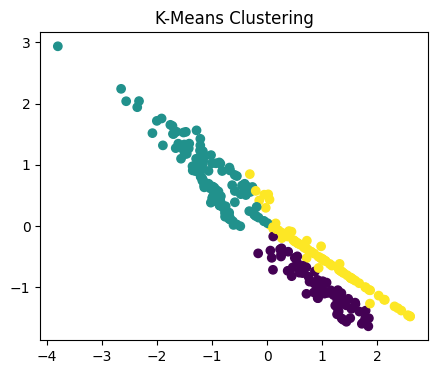

Perceptron Accuracy: 0.9233333333333333
Neural Network Accuracy: 0.9266666666666666


In [10]:
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

## 10(a)
X, y = make_classification(n_samples=300, n_features=4, random_state=42)

## 10(b)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)

## 10(c)
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=clusters)
plt.title("K-Means Clustering")
plt.show()

## 10(d)
perc = Perceptron()
perc.fit(X,y)
acc1 = perc.score(X,y)

## 10(e)
mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000)
mlp.fit(X,y)
acc2 = mlp.score(X,y)

print("Perceptron Accuracy:", acc1)
print("Neural Network Accuracy:", acc2)

##### Submitted By->

- Name: Amulya Shrivastava
- Regd No: 2341019456
- Section: 23412F3
- Serial No: 59
- Semester: 6th
- Branch: B.Tech CSE Core